Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, None, None, 64) │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, None, None, 64) │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, None, None, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, None, None,     │        73,856 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, None, None,     │       147,584 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, None, None,     │       295,168 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, None, None,     │       590,080 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, None, None,     │       590,080 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, None, None,     │     1,180,160 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │             

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

None
Filter shape: (3, 3, 256, 256)
Selected Filters: [210 249 252 200 183  97  90  70]


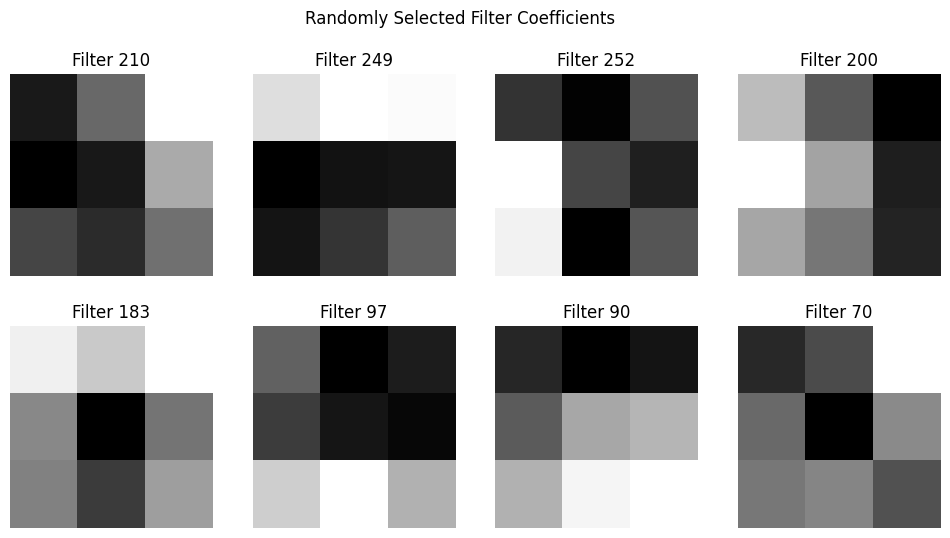

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Feature map shape: (1, 56, 56, 256)


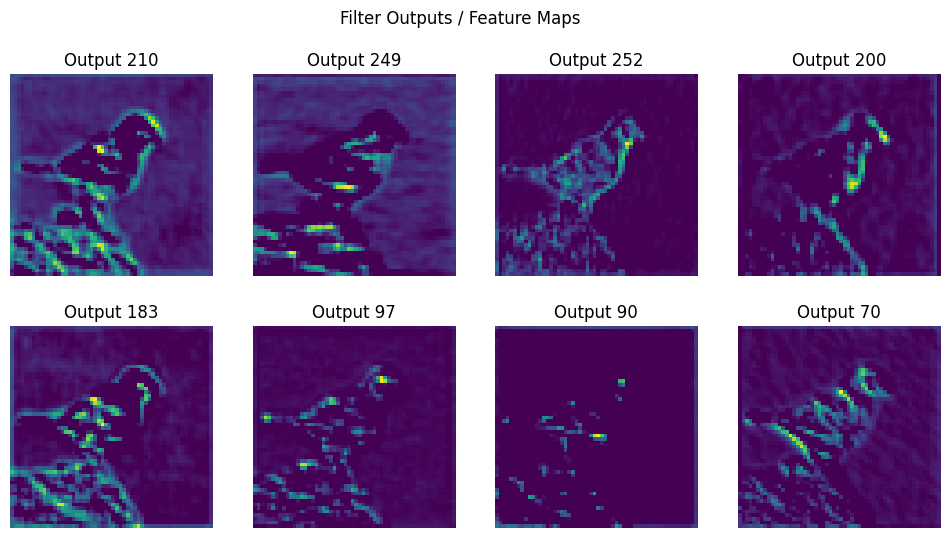


FILTER CLASSIFICATION

Filter 210: High Pass Filter
Filter 249: Low Pass Filter
Filter 252: High Pass Filter
Filter 200: High Pass Filter
Filter 183: High Pass Filter
Filter 97: High Pass Filter
Filter 90: High Pass Filter
Filter 70: High Pass Filter


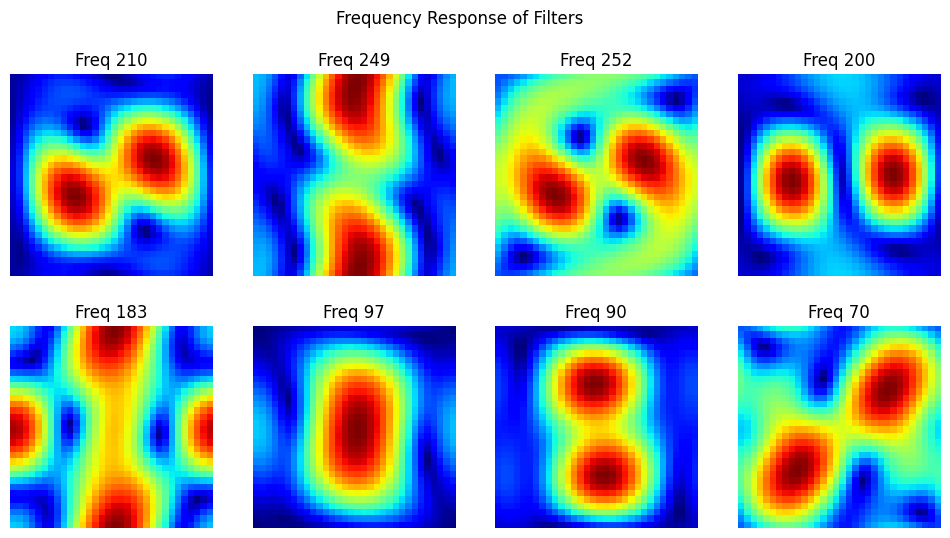

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.models import Model

model = VGG16(weights='imagenet', include_top=False)
print(model.summary())

layer_name = 'block3_conv2'
layer = model.get_layer(layer_name)
filters, biases = layer.get_weights()
print("Filter shape:", filters.shape)

num_filters = filters.shape[3]
random_filters = np.random.choice(num_filters, 8, replace=False)
print("Selected Filters:", random_filters)
fig, axes = plt.subplots(2, 4, figsize=(12,6))

for i, f in enumerate(random_filters):
    ax = axes[i//4, i%4]
    filter_img = filters[:, :, 0, f]
    ax.imshow(filter_img, cmap='gray')
    ax.set_title(f'Filter {f}')
    ax.axis('off')
plt.suptitle("Randomly Selected Filter Coefficients")
plt.show()

img_path = "Painted_Bunting_0102_16642.jpg"
img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
x = np.expand_dims(img_array, axis=0)
x = preprocess_input(x)

feature_model = Model(inputs=model.input, outputs=layer.output)
feature_maps = feature_model.predict(x)
print("Feature map shape:", feature_maps.shape)

fig, axes = plt.subplots(2,4, figsize=(12,6))

for i, f in enumerate(random_filters):
    ax = axes[i//4, i%4]
    feature_map = feature_maps[0, :, :, f]
    ax.imshow(feature_map, cmap='viridis')
    ax.set_title(f'Output {f}')
    ax.axis('off')
plt.suptitle("Filter Outputs / Feature Maps")
plt.show()

print("\nFILTER CLASSIFICATION\n")

for f in random_filters:
    kernel = filters[:, :, 0, f]
    mean_value = np.mean(kernel)
    center = kernel[1,1]
    surrounding = (np.sum(kernel) - center) / 8
    if abs(center) > abs(surrounding):
        category = "High Pass Filter"
    else:
        category = "Low Pass Filter"
    print(f"Filter {f}: {category}")

fig, axes = plt.subplots(2,4, figsize=(12,6))

for i, f in enumerate(random_filters):
    ax = axes[i//4, i%4]
    kernel = filters[:, :, 0, f]
    freq = np.fft.fft2(kernel, s=(32,32))
    freq_shift = np.fft.fftshift(freq)
    magnitude = np.log(np.abs(freq_shift) + 1)
    ax.imshow(magnitude, cmap='jet')
    ax.set_title(f'Freq {f}')
    ax.axis('off')
plt.suptitle("Frequency Response of Filters")
plt.show()